# 07 Coastal Flood Risk (Delft-FIAT)

> **Stage Contract**
>
> Requires: the FIAT model (built here once from NSI + HAZUS), `catalog_risk_metadata.json` from `03`, and completed SFINCS `run_outputs` (from `05` + cluster).
>
> Produces: per-asset damage, Expected Annual Damage (EAD) per SLR scenario, audit receipts, and risk artifacts under `data/fiat/risk`.
>
> Method: Delft-FIAT is the per-event **damage engine**; the probability integration into EAD is done here with the catalog's importance-sampling weights, because the events are *compound* (no single return period). A FIAT-native return-period risk run is included only as a coarse cross-check.

**Environment:** hydromt_fiat / delft_fiat cannot share the main hydromt-1.x SFINCS env, so they live in an isolated conda env (`fiat`). This notebook runs in the main kernel and shells into that env via `fiat_runs` for the build/engine steps; hazard export and EAD integration run here.

In [1]:
import sys, json, time
from pathlib import Path

location_root = Path("..").resolve()
repo_root = location_root.parents[1]
src_root = repo_root / "src"
sys.path.insert(0, str(src_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# flood, forcing, and post-run plots.
from sfincs_runs import diagnostics as sfincs_diagnostics
# risk model paths and tide-gauge output roots.
from fiat_runs.notebook import load_runtime

# damage model runs and expected-loss summaries.
from fiat_runs import (
    env_ready,
    build_model, apply_ground, model_ready,
    WaterLevelRasterizer, run_event, diagnostics, risk, risk_native, validate,
)

runtime = load_runtime(location_root)
config = runtime.config
paths = runtime.paths
catalog_csv = runtime.catalog_csv
metadata_json = runtime.metadata_json
model_root = runtime.model_root
pd.set_option("display.max_columns", 80)

# Completed events to process interactively. EAD is only complete over the full synthetic
# catalog (500 events); set EVENT_LIMIT = None for the headline numbers.
EVENT_LIMIT = None


## Rerun Control


In [ ]:
rerun = False


## Step 0 - Stage input audit

Confirm the isolated FIAT env, the event catalog + risk metadata from `03`, and which SFINCS runs are completed (keyed on their SLR scenario). Hard-fail early with an actionable message.

In [2]:
inputs = {
    "env_ready": env_ready(),
    "fiat_model_built": model_ready(paths),
    "event_catalog": catalog_csv.exists(),
    "catalog_risk_metadata": metadata_json.exists(),
    "storage_root": str(paths["storage_root"]),
}
display(pd.Series(inputs, name="stage_inputs"))

if not inputs["env_ready"]:
    raise RuntimeError(
        "conda 'fiat' env is missing hydromt_fiat/delft_fiat. Create it: "
        "mamba create -n fiat -c conda-forge python=3.12 gdal delft_fiat && "
        "conda run -n fiat pip install hydromt_fiat"
    )
if not (inputs["event_catalog"] and inputs["catalog_risk_metadata"]):
    raise FileNotFoundError(
        "Missing event_catalog.csv or catalog_risk_metadata.json. Run 03_build_event_catalog "
        "(including the catalog_risk_metadata export cell) first."
    )

runs = sfincs_diagnostics.completed_sfincs_runs(paths["storage_root"])
if runs.empty:
    raise RuntimeError("No completed SFINCS run_outputs found. Run 05 + the cluster job first.")

weights = risk.load_catalog_weights(catalog_csv)
total_rate = risk.total_rate_from_metadata(metadata_json)
selected = runs if EVENT_LIMIT is None else runs.groupby("design_scenario", group_keys=False).head(EVENT_LIMIT)

run_coverage_preview = selected[["event_id", "design_scenario"]].merge(weights, on="event_id", how="inner")
display(runs.groupby("design_scenario").size().rename("completed_sfincs_runs"))
display(pd.Series({
    "event_limit": "all_completed" if EVENT_LIMIT is None else EVENT_LIMIT,
    "selected_completed_runs": len(selected),
    "weighted_catalog_events": len(weights),
    "selected_probability_weight": float(run_coverage_preview["probability_weight"].sum()),
    "total_rate_per_year": total_rate,
    "rerun": rerun,
}, name="catalog_probability_preflight"))


fiat_env_available True
fiat_model_built True
event_catalog True
catalog_risk_metadata True
storage_root /home/grahamhults/projects/Flood-RM/locations/...
Name: stage_inputs, dtype: object

design_scenario
base 500
Name: completed_sfincs_runs, dtype: int64

event_limit all_completed
selected_completed_runs 500
weighted_catalog_events 500
selected_probability_weight 1.0
total_rate_per_year 8.93
force_fiat_rerun False
Name: catalog_probability_preflight, dtype: object

## Step 1 - Build the FIAT model (once)

Exposure is the USACE **National Structure Inventory** (NSI); vulnerability is the FEMA/**HAZUS** depth-damage curves; both come from the hydromt_fiat bundled USA catalog (recipe: `fiat_config.yml`). Ground elevation is then re-sampled from the high-resolution **SFINCS subgrid DEM** so the FIAT ground and the SFINCS water level share one vertical datum (offline coupling) - this is what keeps per-structure depths, and damage magnitudes, credible.

In [3]:
if not model_ready(paths):
    receipt = build_model(config, paths)   # one-time NSI pull + HAZUS linking (isolated env)
else:
    receipt = {"reused": True, "model_root": str(model_root)}

# Idempotent: ensure exposure ground elevation comes from the SFINCS DEM (not NSI NAVD88).
ground = apply_ground(config, paths)

display(pd.Series({
    "model_root": str(model_root),
    "n_exposure_assets": receipt.get("n_exposure_assets"),
    "structures_grounded": ground["structures_grounded"],
    "ground_ft_median": round(ground["ground_ft_median"], 2),
    "exposure": "NSI", "vulnerability": "HAZUS IWR curves",
}, name="fiat_model"))


model_root /home/grahamhults/projects/Flood-RM/locations/...
n_exposure_assets None
structures_grounded 13223
ground_ft_median 40.24
exposure NSI
vulnerability HAZUS IWR curves
Name: fiat_model, dtype: object

## Step 1b - Building exposure and vulnerability review

HydroMT-FIAT builds the structure exposure from NSI building points and links them to HAZUS IWR vulnerability curves. This review makes the infrastructure layer visible before event damages are interpreted.


n_building_assets 13230
crs EPSG:4326
occupancy_classes 4
max_potential_structure_damage 5600901728.275599
max_potential_content_damage 3658576042.5912
median_ground_elev_ft 40.241647
grounded_assets 13223
Name: fiat_building_exposure, dtype: object

,n_buildings,max_structure_damage,max_content_damage
primary_object_type,,,
RES,11658,3.998307e+09,1.999153e+09
COM,946,9.399866e+08,9.426020e+08
PUB,421,4.928180e+08,4.965411e+08
IND,205,1.697902e+08,2.202795e+08


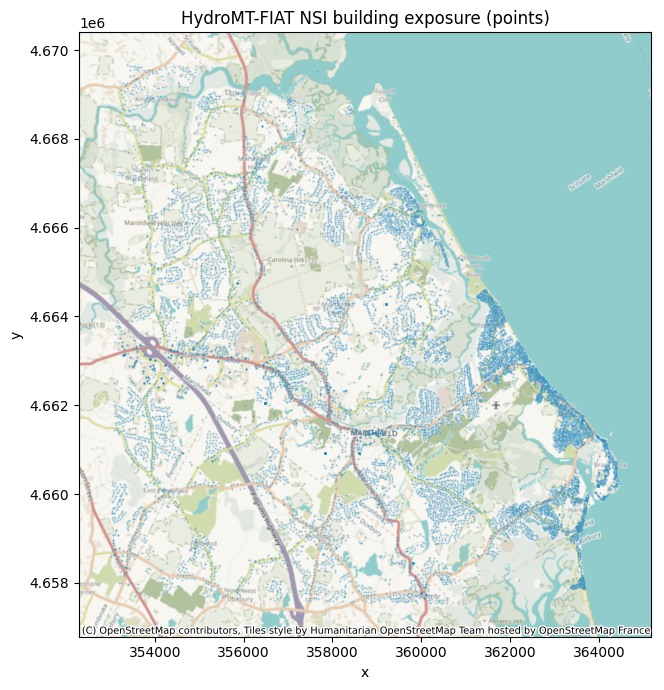

In [4]:
exposure_csv = model_root / "exposure" / "exposure.csv"
vulnerability_csv = model_root / "vulnerability" / "vulnerability_curves.csv"
buildings = diagnostics.load_exposure_buildings(model_root)

exposure_review = diagnostics.exposure_summary(buildings)
display(exposure_review)
display(
 buildings.groupby("primary_object_type", dropna=False).agg(
        n_buildings=("object_id", "size"),
        max_structure_damage=("max_damage_structure", "sum"),
        max_content_damage=("max_damage_content", "sum"),
 ).sort_values("max_structure_damage", ascending=False).head(12)
)

fig, ax = plt.subplots(figsize=(8, 7))
diagnostics.plot_building_exposure(
    buildings,
    ax=ax,
    basemap_style="osm",
    title="HydroMT-FIAT NSI building exposure (points)",
)
plt.tight_layout()


## Step 2 - Export per-event hazard + run Delft-FIAT

For each completed event we rasterise the SFINCS peak **water level** (`zsmax`, feet) onto a regular grid, masked to cells with both event depth (`zsmax - zb`) and storm increment (`zsmax - zs_t0`) above `huthresh`, then run FIAT single-event (`risk=false`). FIAT subtracts each structure's DEM ground elevation and NSI ground-floor height to get inundation depth, applies the HAZUS curve, and returns per-asset structure + content damage.

This notebook **does** provide an event-level FIAT damage screen and a weighted-event EAD calculation over whichever synthetic events are processed. It **does not** calibrate NSI exposure values, validate HAZUS curves against Marshfield claims data, create a FEMA-style flood map, or make a headline EAD when `EVENT_LIMIT` is set. The diagnostic tables below are the review gate for whether big numbers come from hazard, exposure value, vulnerability-curve behavior, or a few high-value assets.

Hazard note: water level is on the 60 m SFINCS grid; the per-structure ground is at 10 m. The wet/incremental mask prevents dry-cell terrain noise and permanent/tidal water from being handed to FIAT as event flooding. The maps below plot **depth** for readability and hide open-water bathymetry so offshore propagation does not dominate landward impact review.

processed 500 FIAT events in 2155s


completed_outcome_events 500.0
catalog_weighted_events 500.0
covered_probability_weight 1.0
catalog_probability_weight 1.0
weight_coverage 1.0
Name: catalog_probability_coverage, dtype: float64

fiat_status
ran 475
reused 25
Name: fiat_event_status, dtype: int64

,event_id,design_scenario,storm_type,severity_band,probability_weight,annual_rate,sample_rp_years,total_damage,n_assets_damaged
162,design_0163,base,nor_easter,common,0.001291,0.011526,4.239852,23191315.40,288
248,design_0249,base,nor_easter,significant,0.000411,0.003667,26.444693,21393603.49,275
395,design_0396,base,nor_easter,extreme,0.000063,0.000563,312.198491,20571696.23,243
203,design_0204,base,nor_easter,significant,0.000411,0.003667,15.618850,17119747.98,178
311,design_0312,base,nor_easter,rare,0.000172,0.001536,86.584368,16658851.70,175
9,design_0010,base,nor_easter,mild,0.029719,0.265393,0.254716,16470182.40,194
462,design_0463,base,other_non_tropical,extreme,0.000063,0.000563,326.936585,15935935.41,196
72,design_0073,base,nor_easter,common,0.001291,0.011526,4.192674,15635033.61,163
234,design_0235,base,nor_easter,significant,0.000411,0.003667,36.253972,14485262.97,146
447,design_0448,base,other_non_tropical,extreme,0.000063,0.000563,101.614512,14166750.06,163


,event_id,design_scenario,total_damage,n_assets_damaged,top10_damage_share_pct,median_inun_depth_ft,p95_inun_depth_ft,low_depth_damage,low_depth_damage_pct,median_loss_ratio,p95_loss_ratio
0,design_0163,base,23191315.40,288,28.129643,0.757720,4.463883,2386188.91,10.289149,0.171480,0.461552
1,design_0249,base,21393603.49,275,29.418772,0.607871,4.271191,2186684.36,10.221206,0.165500,0.452500
2,design_0396,base,20571696.23,243,30.143888,0.769716,4.209290,2039287.34,9.913073,0.168237,0.469450
3,design_0204,base,17119747.98,178,36.783282,1.350957,4.496269,560139.02,3.271888,0.205863,0.486540
4,design_0312,base,16658851.70,175,35.592544,1.260745,4.068987,950652.10,5.706588,0.191333,0.474000
5,design_0010,base,16470182.40,194,34.615301,0.785628,3.819077,1490374.90,9.048928,0.166750,0.459525
6,design_0463,base,15935935.41,196,34.474451,0.749675,3.770742,1430703.25,8.977843,0.160573,0.454250
7,design_0073,base,15635033.61,163,36.977230,0.919934,4.000008,1571410.08,10.050571,0.178200,0.468750
8,design_0235,base,14485262.97,146,39.098668,1.227258,3.920401,751431.93,5.187562,0.198382,0.467625
9,design_0448,base,14166750.06,163,37.340161,0.943766,3.714115,996024.99,7.030723,0.173360,0.454900


,depth_band_ft,n_assets,damage,damage_pct
0,"(-999.0, -5.0]",0,0.00,0.000000
1,"(-5.0, -2.0]",0,0.00,0.000000
2,"(-2.0, 0.0]",109,2386188.91,10.289149
3,"(0.0, 0.5]",23,883027.71,3.807579
4,"(0.5, 1.0]",25,1388393.84,5.986697
5,"(1.0, 2.0]",45,3387869.55,14.608354
6,"(2.0, 4.0]",61,7862644.60,33.903401
7,"(4.0, 8.0]",24,6672152.05,28.770046
8,"(8.0, 999.0]",1,611038.74,2.634774


,primary_object_type,n_assets,damage,damage_pct
0,RES,243,11435474.23,49.309295
1,PUB,29,5967560.50,25.731876
2,COM,15,5770599.80,24.882589
3,IND,1,17680.87,0.076239


,object_id,total_damage,inun_depth,ground_elevtn,ground_flht,max_damage_structure,max_damage_content,primary_object_type,secondary_object_type
0,526233715,2316673.20,6.658405,0.209357,0.5,1855060.060,1855060.060,COM,COM4
1,526255874,1218380.54,2.529757,3.423001,0.5,2118333.230,2118333.230,COM,COM4
2,527025450,611038.74,12.539926,-12.307832,8.0,376255.382,376255.382,COM,COM4
3,527025443,421105.02,5.723447,1.999208,0.5,376255.382,376255.382,PUB,GOV1
4,527025387,380507.06,4.590085,3.214007,0.5,376255.382,376255.382,PUB,GOV1
5,526255869,365068.56,2.272923,3.611040,0.5,688237.234,688237.234,COM,COM4
6,527025413,350293.76,3.605442,4.210291,0.5,376255.382,376255.382,PUB,GOV1
7,527066557,312584.05,3.565818,3.133659,1.5,640252.447,320126.223,RES,RES3A
8,527025212,278719.07,6.062980,-0.178184,0.5,237320.825,237320.825,COM,COM4
9,527025217,269264.20,5.856722,0.073310,0.5,237320.825,237320.825,PUB,GOV1


,damage_function,max_ratio_at_depth_le_0
0,RES1-1SWB_structure,0.255
1,RES1-2SWB_structure,0.179
2,RES1-1SWB_content,0.160
3,IND4_content,0.150
4,RES1-3SWB_content,0.140
5,RES1-1SNB_structure,0.134
6,COM8_content,0.130
7,RES1-2SWB_content,0.119
8,RES1-2SNB_structure,0.093
9,RES1-1SNB_content,0.081


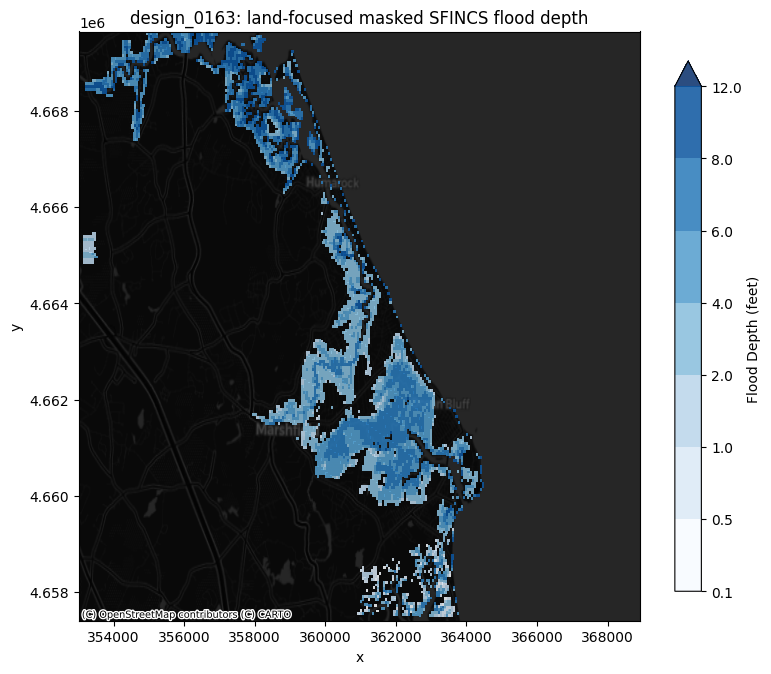

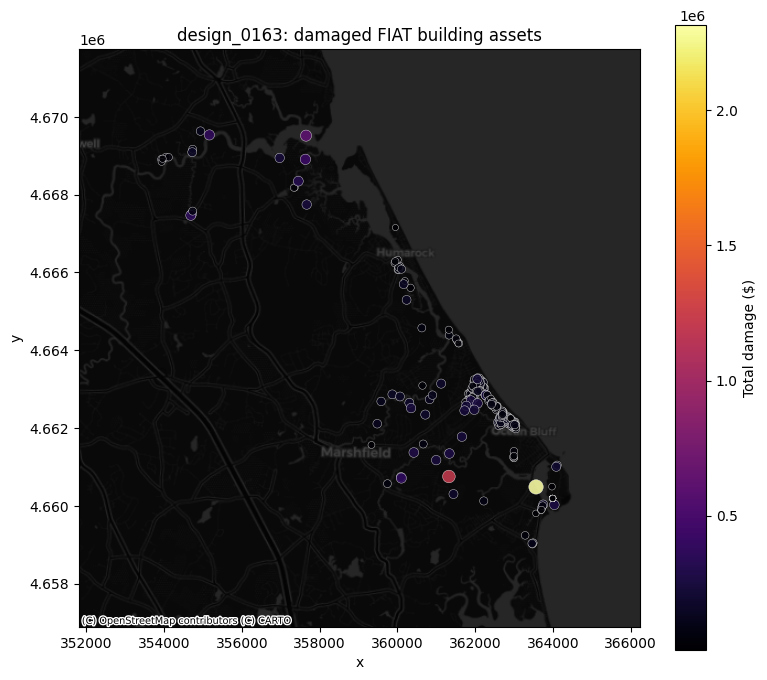

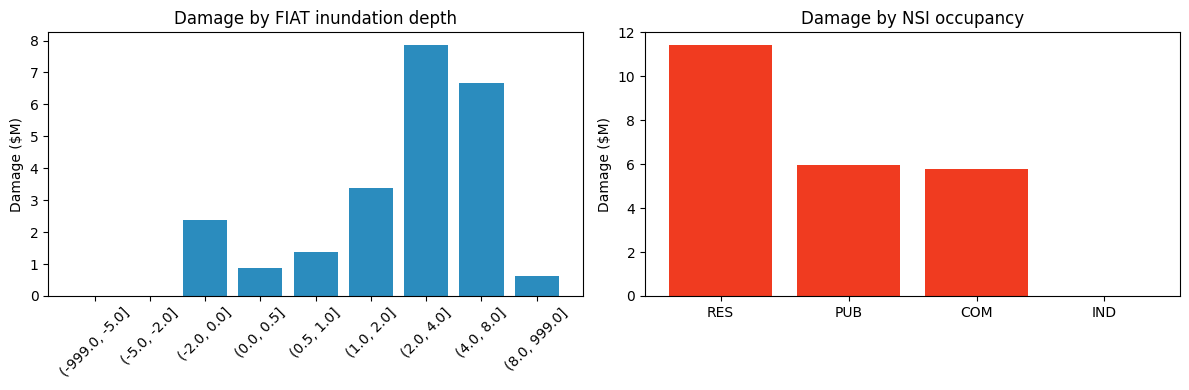

In [5]:
rasterizer = WaterLevelRasterizer(selected.iloc[0]["map_path"])  # grid geometry shared by all runs

damage_rows = []
t0 = time.time()
for r in selected.itertuples(index=False):
    haz = paths["fiat_hazard_root"] / r.design_scenario / f"{r.event_id}.tif"
    out_dir = paths["fiat_risk_root"] / r.design_scenario / r.event_id
    gpkg = out_dir / "spatial.gpkg"
    if rerun or not gpkg.exists():
        rasterizer.export(r.map_path, haz)
        res = run_event(model_root, haz, out_dir, event_id=r.event_id)
        status = "ran"
    else:
        event_damage = diagnostics.event_damage(
            paths["fiat_risk_root"], r.event_id, scenario=r.design_scenario
        )
        total = pd.to_numeric(event_damage.get("total_damage"), errors="coerce").fillna(0.0)
        res = {
            "event_id": r.event_id,
            "total_damage": float(total.sum()),
            "n_assets": int(len(event_damage)),
            "n_assets_damaged": int((total > 0).sum()),
            "output_gpkg": str(gpkg),
        }
        status = "reused"
    res["design_scenario"] = r.design_scenario
    res["fiat_status"] = status
    damage_rows.append(res)

per_event_damage = pd.DataFrame(damage_rows)
event_outcomes = sfincs_diagnostics.event_outcome_table(selected, catalog_csv, weights, total_rate, per_event_damage)
coverage = sfincs_diagnostics.outcome_coverage(event_outcomes, weights)

print(f"processed {len(per_event_damage)} FIAT events in {time.time() - t0:.0f}s")
display(coverage)
display(per_event_damage["fiat_status"].value_counts().rename("fiat_event_status"))
display(event_outcomes.sort_values("total_damage", ascending=False)[[
    "event_id", "design_scenario", "storm_type", "severity_band", "probability_weight",
    "annual_rate", "sample_rp_years", "total_damage", "n_assets_damaged",
]].head(15))

review = per_event_damage.sort_values("total_damage", ascending=False).iloc[0]
review_run = selected[(selected["event_id"] == review.event_id) & (selected["design_scenario"] == review.design_scenario)].iloc[0]
review_damage = diagnostics.event_damage(
    paths["fiat_risk_root"], review.event_id, scenario=review.design_scenario, exposure_csv=exposure_csv
)

audit_rows = []
for r in per_event_damage.sort_values("total_damage", ascending=False).head(12).itertuples(index=False):
    event_damage = diagnostics.event_damage(
        paths["fiat_risk_root"], r.event_id, scenario=r.design_scenario, exposure_csv=exposure_csv
    )
    audit_rows.append({"event_id": r.event_id, "design_scenario": r.design_scenario, **diagnostics.damage_summary(event_damage)})

damage_audit = pd.DataFrame(audit_rows)
display(damage_audit[[
    "event_id", "design_scenario", "total_damage", "n_assets_damaged",
    "top10_damage_share_pct", "median_inun_depth_ft", "p95_inun_depth_ft",
    "low_depth_damage", "low_depth_damage_pct", "median_loss_ratio", "p95_loss_ratio",
]])
display(diagnostics.damage_by_depth(review_damage))
display(diagnostics.damage_by_use(review_damage).head(8))
display(diagnostics.top_assets(review_damage, n=12))
display(diagnostics.nonzero_negative_depth_curves(vulnerability_csv).head(12))

fig, ax = plt.subplots(figsize=(8, 7))
ax, mesh = diagnostics.plot_flood_depth(
    review_run.map_path,
    ax=ax,
    basemap_style="dark",
    land_min_elev_m=-0.5,
    title=f"{review.event_id}: land-focused masked SFINCS flood depth",
)
cbar = fig.colorbar(mesh, ax=ax, shrink=0.9)
cbar.set_label("Flood Depth (feet)")
plt.tight_layout()

fig, ax = plt.subplots(figsize=(8, 7))
diagnostics.plot_damaged_assets(
    review_damage,
    ax=ax,
    basemap_style="dark",
    title=f"{review.event_id}: damaged FIAT building assets",
)
plt.tight_layout()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
depth_bands = diagnostics.damage_by_depth(review_damage)
axes[0].bar(depth_bands["depth_band_ft"].astype(str), depth_bands["damage"] / 1e6, color="#2b8cbe")
axes[0].set_ylabel("Damage ($M)")
axes[0].set_title("Damage by FIAT inundation depth")
axes[0].tick_params(axis="x", rotation=45)
occupancy = diagnostics.damage_by_use(review_damage).head(6)
axes[1].bar(occupancy["primary_object_type"].astype(str), occupancy["damage"] / 1e6, color="#f03b20")
axes[1].set_ylabel("Damage ($M)")
axes[1].set_title("Damage by NSI occupancy")
plt.tight_layout()


## Step 2c - Building-level annualized risk and affected neighborhoods

FIAT outputs are aggregated over the completed weighted catalog to show annualized building damage, building damage probability, and the Census Blockgroups that behave as affected-neighborhood review windows.


In [6]:
building_risk = diagnostics.building_risk(
    paths["fiat_risk_root"],
    event_outcomes,
    scenario="base",
    exposure_csv=exposure_csv,
)
top_neighborhoods = diagnostics.top_neighborhoods(building_risk, n=4)

building_risk_csv = paths["fiat_risk_root"] / "building_annualized_risk.csv"
building_risk_gpkg = paths["fiat_risk_root"] / "building_annualized_risk.gpkg"
building_risk.drop(columns="geometry").to_csv(building_risk_csv, index=False)
building_risk.to_file(building_risk_gpkg, driver="GPKG")

display(top_neighborhoods)
display(building_risk.sort_values("annual_damage", ascending=False)[[
    "object_id", "primary_object_type", "annual_damage", "damage_aep", "max_event_damage",
    "weighted_mean_inun_depth_ft", "max_inun_depth_ft", "aggregation_label:Census Blockgroup",
]].head(15))

fig, ax = plt.subplots(figsize=(8, 7))
diagnostics.plot_risk(
    building_risk,
    metric="annual_damage",
    ax=ax,
    basemap_style="dark",
    title="Annualized building damage from completed weighted catalog",
)
plt.tight_layout()

fig, ax = plt.subplots(figsize=(8, 7))
diagnostics.plot_risk(
    building_risk,
    metric="damage_aep",
    ax=ax,
    basemap_style="dark",
    title="Annual probability of nonzero building damage",
)
plt.tight_layout()

if not top_neighborhoods.empty:
    fig, axes = plt.subplots(1, min(2, len(top_neighborhoods)), figsize=(7 * min(2, len(top_neighborhoods)), 6), squeeze=False)
    for ax, neighborhood in zip(axes[0], top_neighborhoods["aggregation_label:Census Blockgroup"].head(2)):
        diagnostics.plot_risk(
    building_risk,
    metric="annual_damage",
    ax=ax,
            basemap_style="osm",
            neighborhood=neighborhood,
            title=f"Affected neighborhood proxy: {neighborhood}",
        )
    plt.tight_layout()


,aggregation_label:Census Blockgroup,annual_damage,damaged_buildings,max_damage_aep,max_event_damage
0,250235062033001,1.466127e+07,1,0.999801,2883041.59
1,250235061011007,7.744916e+06,3,0.999866,611038.74
2,250235062043007,5.079852e+06,33,0.975876,126981.82
3,250235062043021,3.467086e+06,17,0.981500,254906.30


,object_id,primary_object_type,annual_damage,damage_aep,max_event_damage,weighted_mean_inun_depth_ft,max_inun_depth_ft,aggregation_label:Census Blockgroup
1945,526233715,COM,1.466127e+07,0.999801,2883041.59,4.580196,7.950568,250235062033001
12890,527025450,COM,5.429883e+06,0.999866,611038.74,10.171366,13.530452,250235061011007
12885,527025443,PUB,1.387104e+06,0.989990,426071.60,2.927367,5.839703,250235061011007
3672,526255874,COM,1.107587e+06,0.832490,1218380.54,0.826307,2.529757,250235062032001
13130,527066557,RES,9.604823e+05,0.995443,316707.27,1.018428,3.712400,250235061011013
13126,527066553,RES,9.279281e+05,0.998907,233552.29,2.057516,4.813695,250235061011007
12874,527025387,PUB,9.125957e+05,0.989953,384194.37,1.694687,4.733853,250235041022001
12823,527025317,PUB,8.730616e+05,0.992844,237842.94,2.489425,4.459065,250235062031000
12758,527025338,PUB,7.965369e+05,0.980567,254906.30,3.187573,5.306241,250235062043021
12728,527025217,PUB,7.665582e+05,0.967179,269264.20,3.927723,5.856722,250235062031013


## Step 3 - Weighted-event Expected Annual Damage

`EAD = total_rate_per_year * sum_i (probability_weight_i * loss_i)` over the synthetic events
(`historical_tail` excluded). The audit receipt shows the weight closure (must be ~1.0 over the
full catalog), the rate used, and the `weight_coverage` actually present.

> **Caveat:** with `EVENT_LIMIT` set, `weight_coverage < 1` and the EAD is **partial**. For the
> headline EAD set `EVENT_LIMIT = None` so all synthetic events are included.

total_rate_per_year 8.93
synthetic_weight_sum 1.0
synthetic_event_count 500
expected_event_count 500
events_with_damage_and_weight 500
ead_origins [synthetic_body, synthetic_tail]
Name: ead_audit, dtype: object

,design_scenario,n_events,weight_coverage,total_rate_per_year,expected_event_damage,ead,ead_delta_vs_base
0,base,500,1.0,8.93,5.324772e+06,4.755022e+07,0.0


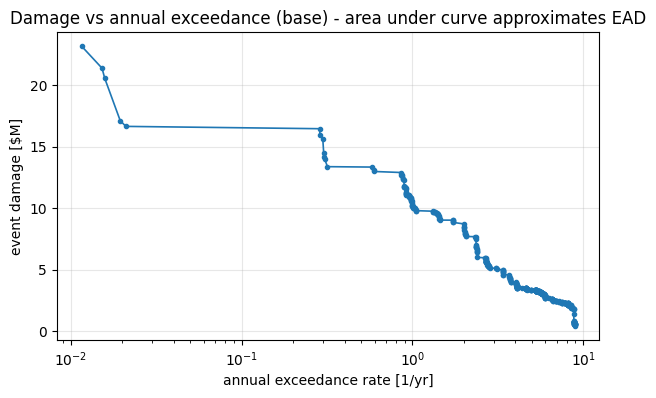

In [7]:
audit = risk.ead_audit(per_event_damage, weights, total_rate, expected_event_count=len(weights))
display(pd.Series({k: v for k, v in audit.items() if k != "ead_by_scenario"}, name="ead_audit"))

ead_table = risk.ead_by_scenario(per_event_damage, weights, total_rate)
display(ead_table)

base_damage = per_event_damage[per_event_damage["design_scenario"] == "base"]
exceedance = risk.exceedance(base_damage, weights, total_rate)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(exceedance["exceedance_rate_per_year"], exceedance["total_damage"] / 1e6, marker=".", lw=1.2)
ax.set_xscale("log")
ax.set_xlabel("annual exceedance rate [1/yr]")
ax.set_ylabel("event damage [$M]")
ax.set_title("Damage vs annual exceedance (base) - area under curve approximates EAD")
ax.grid(True, alpha=0.3)
plt.show()


## Step 4 - FIAT-native return-period risk (cross-check)

Independent sanity bound: pick the synthetic event nearest each target return period (10/50/100/500 yr by joint RP), stack their water-level maps as RP bands, and let Delft-FIAT integrate EAD log-linearly over the exceedance probabilities. This is **approximate** (joint RP != marginal RP; one event per RP) and is expected to differ from the weighted-event EAD - it is a bound, not ground truth.

In [8]:
rp_events = risk_native.select_rp(catalog_csv)
native = risk_native.run_rp_risk(
    model_root, rasterizer, paths["storage_root"], rp_events,
    paths["fiat_risk_root"] / "_native_rp", paths["fiat_hazard_root"] / "_native_rp",
)
display(pd.Series(native, name="native_rp_risk"))
base_ead = ead_table.loc[ead_table["design_scenario"] == "base", "ead"]
if len(base_ead):
    display(pd.Series({
        "weighted_event_ead_base": float(base_ead.iloc[0]),
        "native_rp_ead": native["ead"],
        "ratio_native_over_weighted": native["ead"] / float(base_ead.iloc[0]) if base_ead.iloc[0] else None,
    }, name="ead_crosscheck"))


method fiat_native_rp_risk
return_periods [10, 50, 100, 500]
rp_events {10: 'design_0173', 50: 'design_0309', 100: 'd...
ead 644256.92
ead_column ead_damage
Name: native_rp_risk, dtype: object

weighted_event_ead_base 4.755022e+07
native_rp_ead 6.442569e+05
ratio_native_over_weighted 1.354898e-02
Name: ead_crosscheck, dtype: float64

## Step 5 - Historical-event validation

Run FIAT on the real `historical_tail` storms (e.g. the 1991 and 1992 nor'easters) as a
non-parametric check - their modeled damage should sit plausibly within the synthetic
distribution. Not used in the EAD. Requires the historical events to have completed SFINCS
runs (stage + run them like the SLR scenarios); missing runs are reported, not fatal.

In [9]:
hist = validate.validate_history(
    model_root, rasterizer, paths["storage_root"], catalog_csv,
    paths["fiat_risk_root"] / "historical", paths["fiat_hazard_root"] / "historical",
)
display(pd.Series({k: v for k, v in hist.items() if k != "damages"}, name="historical_validation"))
if hist["n_run"]:
    display(hist["damages"][["event_id", "total_damage", "n_assets_damaged", "coastal_absolute_peak_m"]])
else:
    print("No historical SFINCS runs yet - stage and run the historical_tail events through 05 + cluster.")


n_historical 10
n_run 0
missing_sfincs_runs [historical_20100224T060000, historical_202110...
Name: historical_validation, dtype: object

No historical SFINCS runs yet - stage and run the historical_tail events through 05 + cluster.


## Step 6 - Write risk outputs

In [10]:
risk_root = paths["fiat_risk_root"]
risk_root.mkdir(parents=True, exist_ok=True)

per_event_damage.to_csv(risk_root / "per_event_damage.csv", index=False)
event_outcomes.to_csv(risk_root / "fiat_event_outcomes_with_catalog_weights.csv", index=False)
ead_table.to_csv(risk_root / "ead_by_scenario.csv", index=False)
exceedance.to_csv(risk_root / "damage_exceedance_base.csv", index=False)
(risk_root / "ead_audit.json").write_text(json.dumps(audit, indent=2, default=str), encoding="utf-8")
(risk_root / "ead_crosscheck.json").write_text(json.dumps(native, indent=2, default=str), encoding="utf-8")
if hist["n_run"]:
    hist["damages"].to_csv(risk_root / "historical_validation.csv", index=False)

summary = {
    "event_count": int(len(per_event_damage)),
    "event_limit": EVENT_LIMIT,
    "rerun": rerun,
    "scenarios": sorted(per_event_damage["design_scenario"].unique().tolist()),
    "total_rate_per_year": total_rate,
    "synthetic_weight_sum": audit["synthetic_weight_sum"],
    "probability_weight_coverage": float(coverage["weight_coverage"]),
    "covered_probability_weight": float(coverage["covered_probability_weight"]),
    "weighted_ead_by_scenario": ead_table.to_dict("records"),
    "native_rp_ead": native.get("ead"),
    "historical_runs": hist["n_run"],
    "building_annualized_risk_csv": str(building_risk_csv),
    "building_annualized_risk_gpkg": str(building_risk_gpkg),
}
(risk_root / "summary.json").write_text(json.dumps(summary, indent=2, default=str), encoding="utf-8")
display(pd.Series({
    "per_event_damage": str(risk_root / "per_event_damage.csv"),
    "fiat_event_outcomes": str(risk_root / "fiat_event_outcomes_with_catalog_weights.csv"),
    "building_annualized_risk": str(building_risk_gpkg),
    "ead_by_scenario": str(risk_root / "ead_by_scenario.csv"),
    "summary": str(risk_root / "summary.json"),
}, name="risk_outputs"))


per_event_damage /home/grahamhults/projects/Flood-RM/locations/...
fiat_event_outcomes /home/grahamhults/projects/Flood-RM/locations/...
building_annualized_risk /home/grahamhults/projects/Flood-RM/locations/...
ead_by_scenario /home/grahamhults/projects/Flood-RM/locations/...
summary /home/grahamhults/projects/Flood-RM/locations/...
Name: risk_outputs, dtype: str